In [25]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

Device : cpu


In [31]:
import pandas as pd

df = pd.read_csv(
    "data/SMSSpamCollection/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "text"],
    encoding="latin-1"
)

print(df.head())
print(df.shape)

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [32]:
import re
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch

# Nettoyage du texte
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)

# Conversion des labels
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Tokenisation
df["tokens"] = df["text"].apply(lambda x: x.split())

# Construction du vocabulaire
counter = Counter()

for tokens in df["tokens"]:
    counter.update(tokens)

VOCAB_SIZE = 10000

vocab = {"<PAD>": 0, "<UNK>": 1}

for word, _ in counter.most_common(VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print("Taille du vocabulaire :", len(vocab))

# Encodage
MAX_LEN = 50

def encode(tokens):
    ids = [vocab.get(word, 1) for word in tokens]

    if len(ids) > MAX_LEN:
        ids = ids[:MAX_LEN]
    else:
        ids += [0] * (MAX_LEN - len(ids))

    return ids

df["encoded"] = df["tokens"].apply(encode)

X = np.array(df["encoded"].tolist())
y = df["label"].values

# Découpage Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Dataset PyTorch
class SMSDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

train_dataset = SMSDataset(X_train, y_train)
test_dataset = SMSDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train :", len(train_dataset))
print("Test :", len(test_dataset))

Taille du vocabulaire : 7787
Train : 4457
Test : 1115


In [33]:
class SimpleRNN(nn.Module):

    def __init__(self):
        super(SimpleRNN, self).__init__()

        self.embedding = nn.Embedding(len(vocab), 128)

        self.rnn = nn.RNN(
            input_size=128,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 2)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        out = self.fc(hidden.squeeze(0))

        return out


rnn_model = SimpleRNN().to(device)

print(rnn_model)

SimpleRNN(
  (embedding): Embedding(7787, 128)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


Epoch 1/5 - Loss : 0.4072
Epoch 2/5 - Loss : 0.3981
Epoch 3/5 - Loss : 0.4001
Epoch 4/5 - Loss : 0.3955
Epoch 5/5 - Loss : 0.3944

Accuracy : 0.862780269058296
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       966
           1       0.00      0.00      0.00       149

    accuracy                           0.86      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.86      0.80      1115



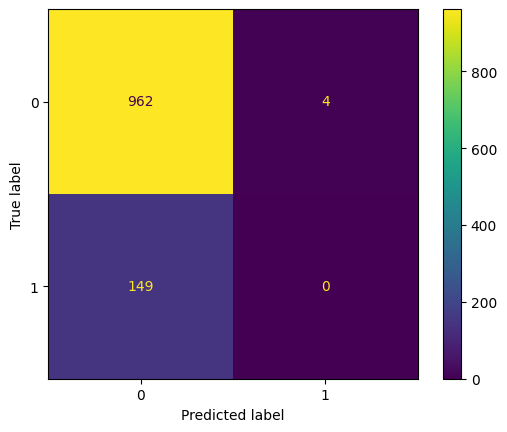

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):

    rnn_model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = rnn_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss : {total_loss/len(train_loader):.4f}")

# ===============================
# Evaluation
# ===============================

rnn_model.eval()

predictions = []
labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = rnn_model(X_batch)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        predictions.extend(preds)

        labels.extend(y_batch.numpy())

print("\nAccuracy :", accuracy_score(labels, predictions))

print(classification_report(labels, predictions))

ConfusionMatrixDisplay.from_predictions(labels, predictions)

plt.show()

rnn_acc = accuracy_score(labels, predictions)

Epoch 1/5 - Loss = 0.4188
Epoch 2/5 - Loss = 0.3982
Epoch 3/5 - Loss = 0.3949
Epoch 4/5 - Loss = 0.3927
Epoch 5/5 - Loss = 0.3933

Accuracy : 0.8663677130044843
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       966
           1       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

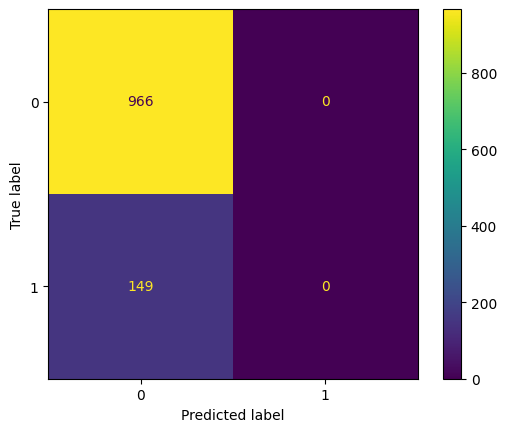

In [42]:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(len(vocab), 128)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 2)

    def forward(self, x):

        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        return self.fc(hidden.squeeze(0))


lstm_model = LSTMModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):

    lstm_model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss = {running_loss/len(train_loader):.4f}")

# =======================
# Evaluation
# =======================

lstm_model.eval()

predictions = []
labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = lstm_model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

        labels.extend(y_batch.numpy())

lstm_acc = accuracy_score(labels, predictions)

print("\nAccuracy :", lstm_acc)

print(classification_report(labels, predictions))

ConfusionMatrixDisplay.from_predictions(labels, predictions)

plt.show()

Epoch 1/5 - Loss = 0.3958
Epoch 2/5 - Loss = 0.1528
Epoch 3/5 - Loss = 0.0450
Epoch 4/5 - Loss = 0.0268
Epoch 5/5 - Loss = 0.0173

Accuracy : 0.9811659192825112
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.96      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



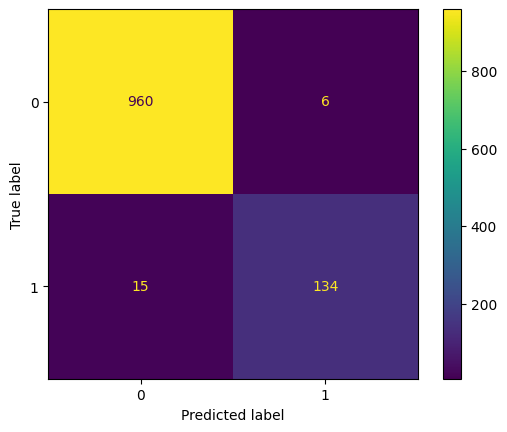

In [43]:
class GRUModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(len(vocab), 128)

        self.gru = nn.GRU(
            input_size=128,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 2)

    def forward(self, x):

        x = self.embedding(x)

        _, hidden = self.gru(x)

        return self.fc(hidden.squeeze(0))


gru_model = GRUModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):

    gru_model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = gru_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss = {running_loss/len(train_loader):.4f}")

# =======================
# Evaluation
# =======================

gru_model.eval()

predictions = []
labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = gru_model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

        labels.extend(y_batch.numpy())

gru_acc = accuracy_score(labels, predictions)

print("\nAccuracy :", gru_acc)

print(classification_report(labels, predictions))

ConfusionMatrixDisplay.from_predictions(labels, predictions)

plt.show()

In [44]:
print("rnn_acc =", rnn_acc)
print("lstm_acc =", lstm_acc)
print("gru_acc =", gru_acc)

rnn_acc = 0.862780269058296
lstm_acc = 0.8663677130044843
gru_acc = 0.9811659192825112


In [45]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Accuracy": [rnn_acc, lstm_acc, gru_acc]
})

print(results)

  Model  Accuracy
0   RNN  0.862780
1  LSTM  0.866368
2   GRU  0.981166


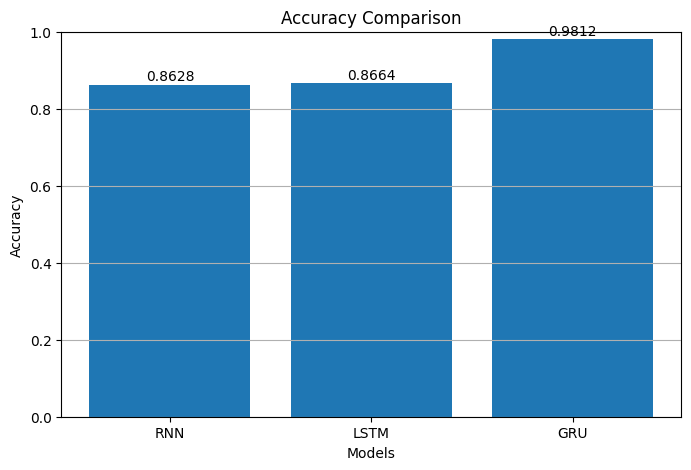

In [46]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha="center")

plt.ylim(0, 1)

plt.grid(axis="y")

plt.show()

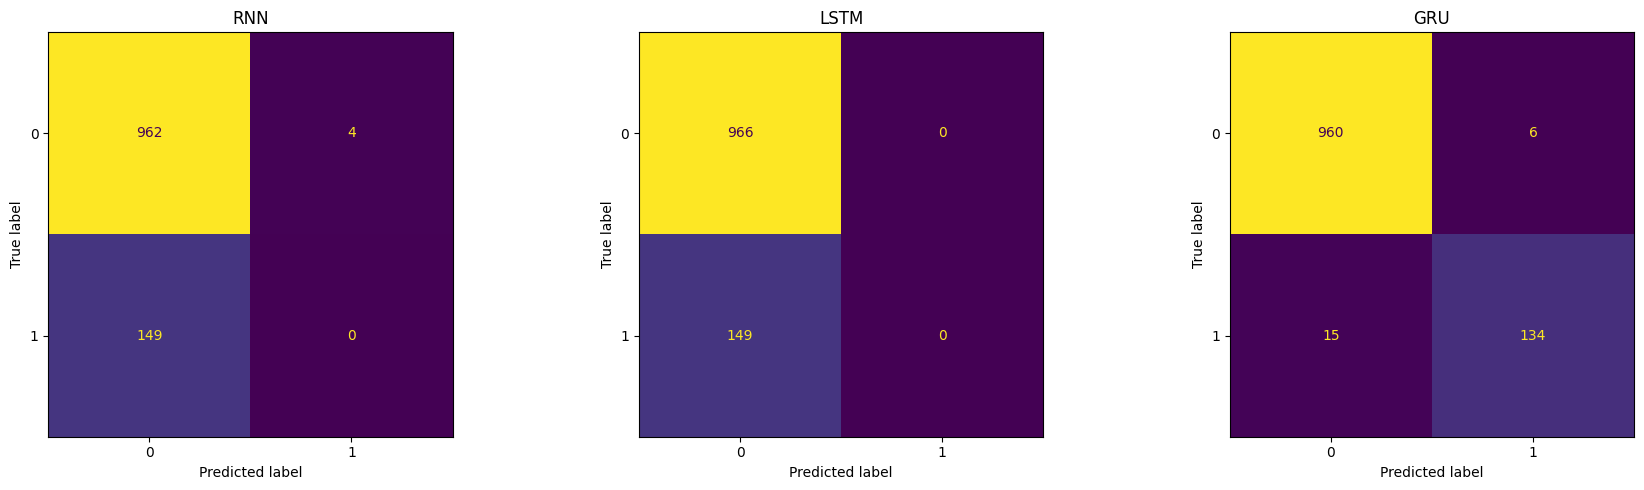

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("GRU", gru_model)
]

for ax, (name, model) in zip(axes, models):

    predictions = []
    labels = []

    model.eval()

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            preds = torch.argmax(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())

            labels.extend(y_batch.numpy())

    cm = confusion_matrix(labels, predictions)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot(ax=ax, colorbar=False)

    ax.set_title(name)

plt.tight_layout()

plt.show()

In [48]:
torch.save(rnn_model.state_dict(), "rnn_sms.pth")

torch.save(lstm_model.state_dict(), "lstm_sms.pth")

torch.save(gru_model.state_dict(), "gru_sms.pth")

print("Les trois modèles ont été sauvegardés.")

Les trois modèles ont été sauvegardés.


In [49]:
def predict(model, text):

    text = clean_text(text)

    tokens = text.split()

    ids = [vocab.get(word, 1) for word in tokens]

    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]

    x = torch.tensor([ids], dtype=torch.long).to(device)

    model.eval()

    with torch.no_grad():

        output = model(x)

        pred = torch.argmax(output, dim=1).item()

    return "Spam" if pred == 1 else "Ham"

In [50]:
sms1 = "Congratulations! You have won a free iPhone. Click here now!"

sms2 = "Hi Hafsa, don't forget our meeting tomorrow at 10 AM."

print("Message 1 :", predict(gru_model, sms1))
print("Message 2 :", predict(gru_model, sms2))

Message 1 : Spam
Message 2 : Ham


In [51]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("="*60)
print("FINAL COMPARISON")
print("="*60)

print(results)

print("\nBest Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"], 4))

FINAL COMPARISON
  Model  Accuracy
0   RNN  0.862780
1  LSTM  0.866368
2   GRU  0.981166

Best Model : GRU
Accuracy : 0.9812
